# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#### 2. Lee una imagen
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [3]:
image = plt.imread('data/ejer_kmeans.png')
image.shape

(764, 1499, 3)

Muestra la imagen para ver que se ha cargado bien

(np.float64(-0.5), np.float64(1498.5), np.float64(763.5), np.float64(-0.5))

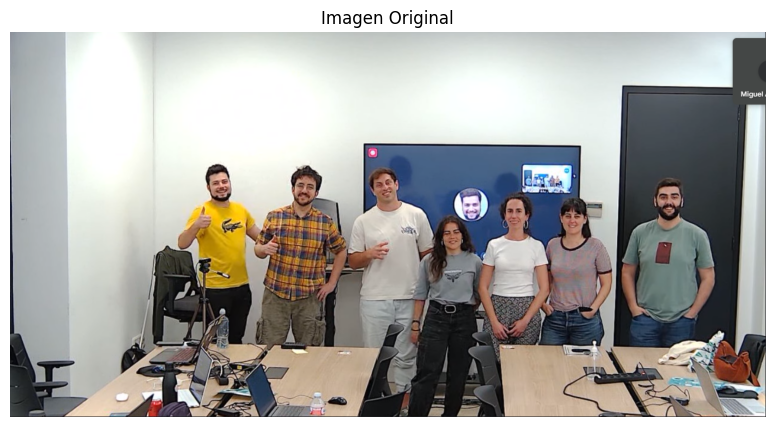

In [4]:
plt.figure(figsize=(10, 5))
plt.imshow(image)
plt.title("Imagen Original")
plt.axis('off')

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [24]:
# Guardamos la forma original para poder restaurarla después
original_shape = image.shape

# Reshapeamos: multiplicamos alto por ancho para obtener el número total de píxeles
# -1 en reshape significa "calcula esta dimensión automáticamente"
pixels = image.reshape(-1, 3)

pixels.shape

(1145236, 3)

#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [22]:
# Inicializamos y entrenamos el modelo KMeans
# n_init=10 es recomendable para asegurar que encontramos buenos centroides
kmeans = KMeans(n_clusters=16, random_state=42, n_init=10)
kmeans.fit(pixels)

print("Entrenamiento completado.")

Entrenamiento completado.


#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizlos para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [23]:
# Obtenemos las etiquetas (a qué cluster pertenece cada píxel)
# labels = kmeans.labels_

# # Obtenemos los colores de los centroides
# centroids = kmeans.cluster_centers_

# # Creamos la nueva imagen usando los centroides correspondientes a cada etiqueta
# # centroids[labels] busca el color del centroide para cada píxel
# new_pixels = kmeans.cluster_centers_[kmeans.labels_]

# Es importante asegurar que los valores estén en el rango correcto (0-255 si es uint8, o 0-1 si es float)
# Dependiendo de cómo leyó matplotlib la imagen, puede estar en 0-1 o 0-255.
# Vamos a asegurar que esté en el mismo tipo que la original
new_pixels = kmeans.cluster_centers_[kmeans.labels_].astype(image.dtype)

print("Píxeles sustituidos por centroides.")

Píxeles sustituidos por centroides.


#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [25]:
# Reshapeamos de nuevo a las dimensiones originales (alto, ancho, 3)
new_image = new_pixels.reshape(original_shape)

print("Forma restaurada:", new_image.shape)

Forma restaurada: (764, 1499, 3)


#### 7. Muestra y guarda en tu ordenador la imagen resultante

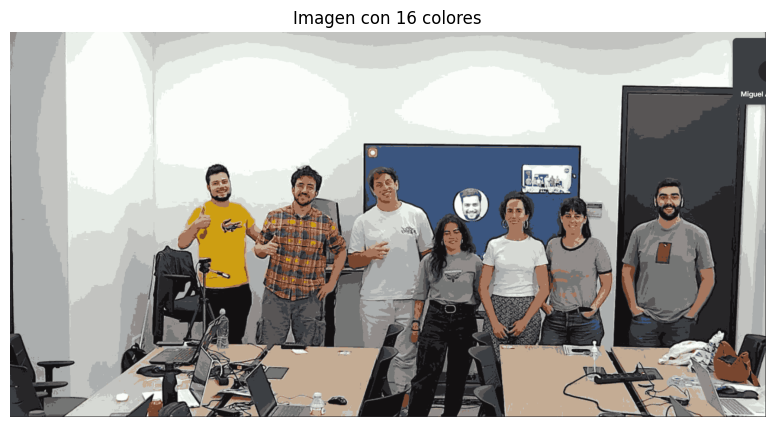

Imagen guardada como 'data/imagen_reducida.png'


In [27]:
# Mostramos la imagen con colores reducidos
plt.figure(figsize=(10, 5))
plt.imshow(new_image)
plt.title(f"Imagen con {16} colores")
plt.axis('off')
plt.show()

# Opcional: Guardar la imagen en tu ordenador
plt.imsave('data/imagen_reducida.png', new_image)
print("Imagen guardada como 'data/imagen_reducida.png'")

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [20]:
def reducir_colores_imagen(ruta_imagen, n_colores=16, guardar=False, nombre_archivo='resultado.png'):
    """
    Reduce el número de colores de una imagen usando KMeans.
    
    Parámetros:
    - ruta_imagen: Ruta del archivo de imagen.
    - n_colores: Número de colores finales deseados.
    - guardar: Booleano, si True guarda la imagen.
    - nombre_archivo: Nombre del archivo si se guarda.
    """
    # 1. Leer imagen
    img = plt.imread(ruta_imagen)
    original_shape = img.shape
    
    # 2. Aplanar la imagen
    pixels = img.reshape(-1, 3)
    
    # 3. Aplicar KMeans
    kmeans = KMeans(n_clusters=n_colores, random_state=42, n_init=10)
    kmeans.fit(pixels)
    
    # 4. Sustituir por centroides
    new_pixels = kmeans.cluster_centers_[kmeans.labels_]
    new_pixels = new_pixels.astype(img.dtype)
    
    # 5. Restaurar forma
    new_image = new_pixels.reshape(original_shape)
    
    # 6. Mostrar
    plt.figure(figsize=(8, 8))
    plt.imshow(new_image)
    plt.title(f"Imagen con {n_colores} colores")
    plt.axis('off')
    plt.show()
    
    # 7. Guardar si se solicita
    if guardar:
        plt.imsave(nombre_archivo, new_image)
        print(f"Imagen guardada como {nombre_archivo}")

# Ejemplo de uso de la función:
# reducir_colores_imagen('data/ejer_kmeans.png', n_colores=8, guardar=True, nombre_archivo='mi_imagen_8_colores.png')